# 1. CNN Model

In [42]:
!pip install tensorflow
!pip install opencv-python-headless


In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [44]:
#This dictionary maps numeric labels (0–9) to their corresponding FashionMNIST clothing categories. It’s useful for displaying predictions in human-readable format.
labels = {
    0 : "T-shirt/top", 
    1: "Trouser", 
    2: "Pullover", 
    3: "Dress", 
    4: "Coat",
    5: "Sandal", 
    6: "Shirt", 
    7: "Sneaker", 
    8: "Bag", 
    9: "Ankle Boot"
}

## Split Training CSV into Two Files
We split the original `fashon-mnist_train.csv` into two separate files.
This was done due to memory limitations on github file sizes


In [45]:
def split_csv():
    try:
        train_path_1 = os.path.join('..', 'data', 'fashon-mnist_train.csv')
        training_df = pd.read_csv(train_path_1)

        mid_point = len(training_df) // 2
        
        # Split the DataFrame
        df_1 = training_df.iloc[:mid_point]
        df_2 = training_df.iloc[mid_point:]
        file_1 = os.path.join('..', 'data', 'fashon-mnist_training_1.csv')
        file_2 = os.path.join('..', 'data', 'fashon-mnist_training_2.csv')
        # Save the two DataFrames into separate CSVs
        df_1.to_csv(file_1, index=False)
        df_2.to_csv(file_2, index=False)
        print("Data successfully split into two files: 'fashon-mnist_train_1.csv' and 'fashon-mnist_train_2.csv'")
    except Exception as e:
        print("If you see fashon-mnist_training_1.csv and fashon-mnist_training_2.csv in the data folder then please ignore this error. \n", e)

split_csv()

If you see fashon-mnist_training_1.csv and fashon-mnist_training_2.csv in the data folder then please ignore this error. 
 [Errno 2] No such file or directory: '../data/fashon-mnist_train.csv'


## Load the Data from CSV Files
This function loads the two split training files and the test file, then merges the training halves.
Returns: `training_df` and `test_df`

In [46]:
def load_data():
    """
    Load the training and testing CSV files.
    """

    train_path_1 = os.path.join('..', 'data', 'fashon-mnist_training_1.csv')
    train_path_2 = os.path.join('..', 'data', 'fashon-mnist_training_2.csv')
    test_path = os.path.join('..', 'data', 'fashon-mnist_test.csv')
    
    train_df_1 = pd.read_csv(train_path_1)
    train_df_2 = pd.read_csv(train_path_2)
    test_df = pd.read_csv(test_path)

    combined_training_df = pd.concat([train_df_1, train_df_2], ignore_index=True)
    return combined_training_df, test_df


    # Load the data
training_df, test_df = load_data()

##  Dataset Summary
This cell displays the number of rows and columns in the training and testing datasets.
It also outputs data types and basic structure using `df.info()`.


In [47]:
def explore_data_info(train_df, test_df):
    """Display basic information about the dataset."""
    print("\nFashion MNIST train -  rows:",train_df.shape[0]," columns:", train_df.shape[1])
    print("\nFashion MNIST test -  rows:",test_df.shape[0]," columns:", test_df.shape[1])
    print("\n--- Training Data Info ---\n")
    print(train_df.info())
    print("\n--- Testing Data Info ---\n")
    print(test_df.info())

explore_data_info(training_df, test_df)


Fashion MNIST train -  rows: 60000  columns: 785

Fashion MNIST test -  rows: 10000  columns: 785

--- Training Data Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB
None

--- Testing Data Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB
None


## Display One Image per Class (Function)
Defines a function to extract and visualize a single example from each FashionMNIST class.
This gives a quick visual understanding of the image types and variations.


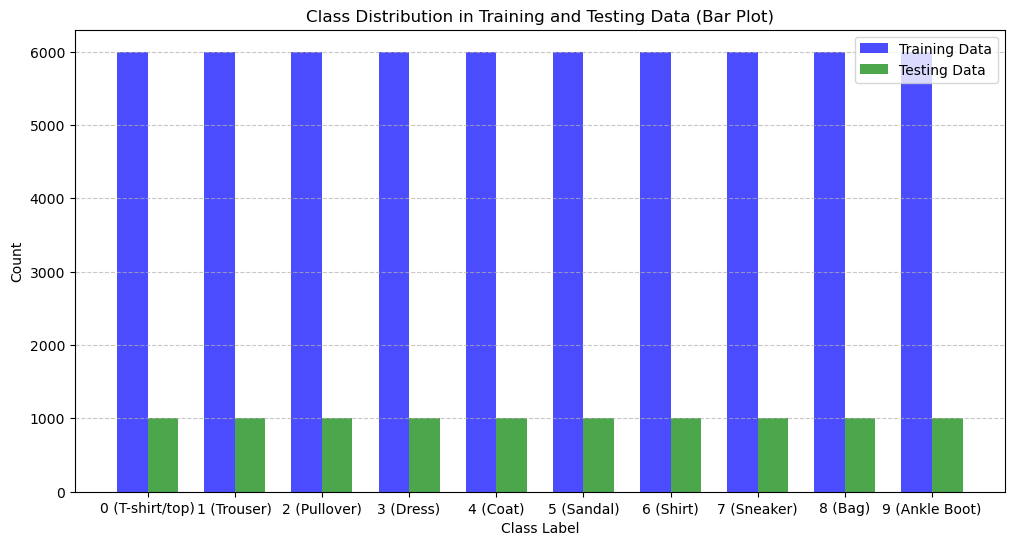

In [48]:
def plot_stacked_area(train_df, test_df):
    """
    Plot class distribution using a stacked area plot for visual comparison.
    """
    # Get class distribution
    train_counts = train_df.iloc[:, 0].value_counts().sort_index()
    test_counts = test_df.iloc[:, 0].value_counts().sort_index()

    # Create a DataFrame for plotting
    plot_data = pd.DataFrame({
        'Class': train_counts.index,
        'Train Count': train_counts.values,
        'Test Count': test_counts.values
    })

    # Plot bar graph with side-by-side bars
    width = 0.35
    x = np.arange(len(plot_data['Class']))

    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, plot_data['Train Count'], width=width, label='Training Data', color='blue', alpha=0.7)
    plt.bar(x + width/2, plot_data['Test Count'], width=width, label='Testing Data', color='green', alpha=0.7)

    plt.xlabel('Class Label')
    plt.ylabel('Count')
    plt.title('Class Distribution in Training and Testing Data (Bar Plot)')
    plt.xticks(x, [f'{cls} ({labels[cls]})' for cls in plot_data['Class']])
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

plot_stacked_area(training_df, test_df)

## Visualize Sample Training Images
Calls the function to plot one sample image from each training class.
Useful for understanding raw input quality and visual differences between categories

In [49]:

def plot_one_image_per_class(df):
    """
    Plot one sample image from each class arranged from class 0 to 9 with text labels.
    """
    
    X = df.iloc[:, 1:].values
    y = df.iloc[:, 0].values

    # Find one image per class
    sample_images = []
    for label in range(10):
        index = np.where(y == label)[0][0]
        sample_images.append((X[index], label))

    plt.figure(figsize=(15, 7))
    for i, (image, label) in enumerate(sample_images):
        plt.subplot(2, 5, i + 1)
        plt.imshow(image.reshape(28, 28), cmap='gray')
        plt.title(f'{label}: {labels[label]}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()



 Sample Image from Training Data Set 



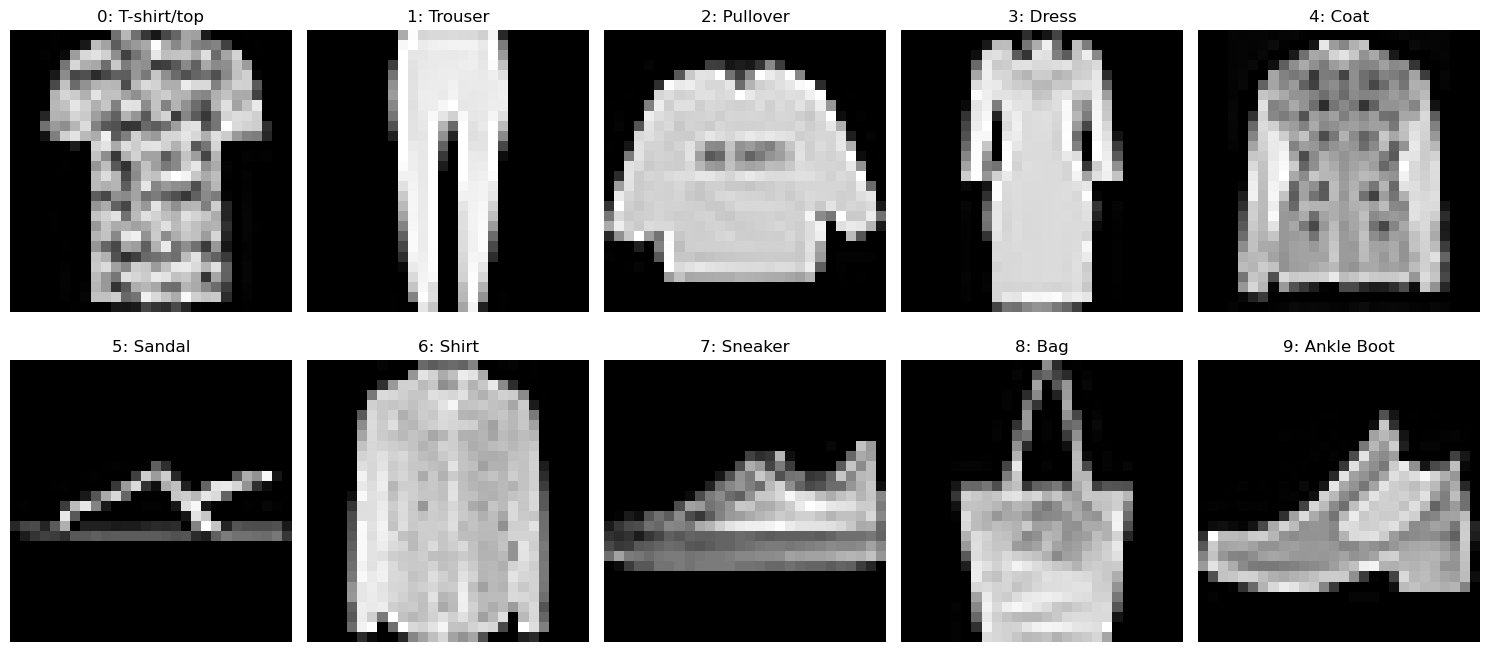

In [50]:
print("\n Sample Image from Training Data Set \n")
plot_one_image_per_class(training_df)



 Sample Image from Test Data Set 



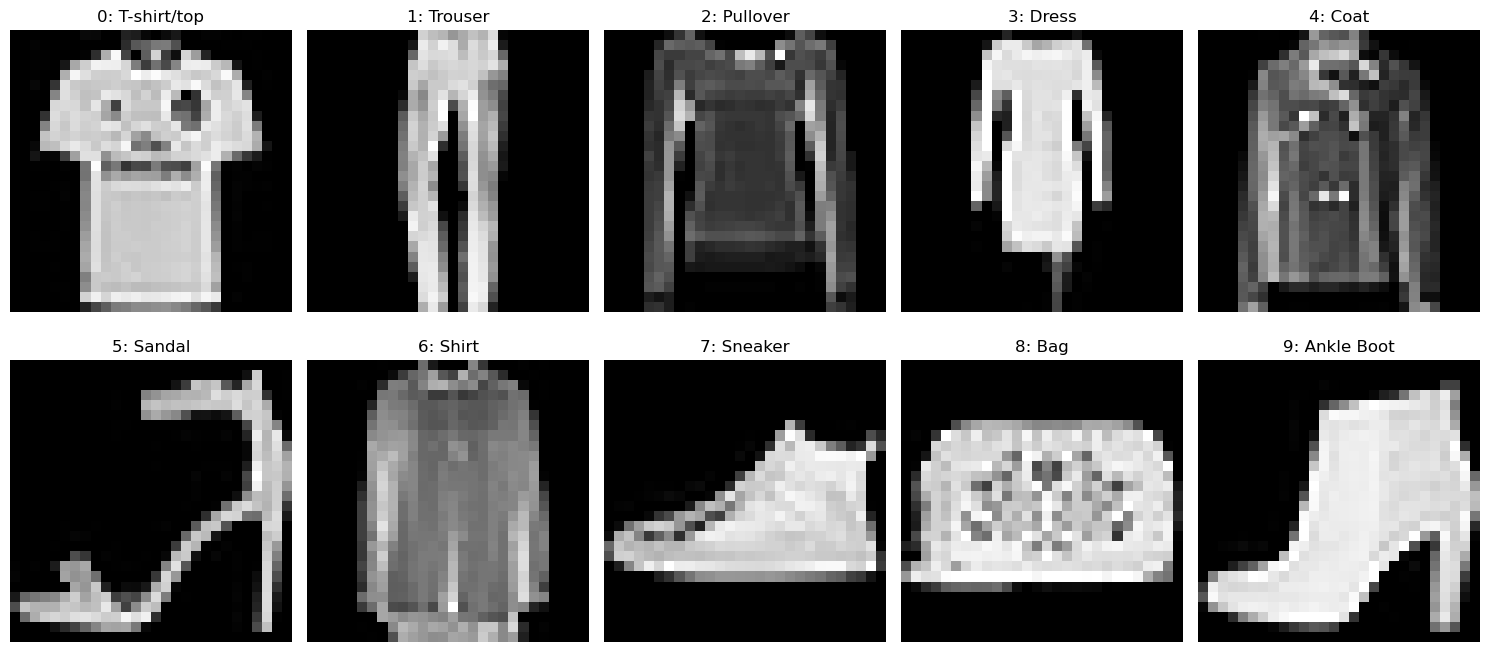

In [51]:
print("\n Sample Image from Test Data Set \n")
plot_one_image_per_class(test_df)

##  Preprocessing + CNN Model Definition
Defines the preprocessing pipeline:
- Normalizes pixel values to [0, 1]
- Reshapes input to (28, 28, 1) for CNN
- One-hot encodes the labels

Then defines a basic CNN model using Conv2D → MaxPooling → Dense layers.


## Train + Evaluate the CNN (Main)
This block runs the full pipeline:
1. Preprocess the data
2. Build and compile the model
3. Train the model
4. Evaluate performance on test set

You should see test accuracy printed at the end.


In [52]:

def preprocess_for_cnn(df):
    """
    Preprocess the dataframe for CNN training:
    - Normalize pixel values to [0, 1]
    - Reshape to (28, 28, 1)
    - Convert labels to one-hot encoded vectors
    """
    X = df.iloc[:, 1:].values.astype('float32') / 255.0  # Normalize pixel values
    X = X.reshape(-1, 28, 28, 1)                           # Reshape for CNN
    y = to_categorical(df.iloc[:, 0].values, num_classes=10)  # One-hot encode labels
    return X, y


def build_cnn_model():
    """
    Build and compile the CNN model.
    """
    model = Sequential([
        # First convolutional block
        Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Second convolutional block
        Conv2D(64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Fully connected layers
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def train_cnn_model(model, X_train, y_train, epochs=10, batch_size=128):
    """
    Train the CNN model on the training data.
    """
    history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
    model.save('fashion_mnist_cnn_model.keras')  # Save the model
    print("Model saved as 'fashion_mnist_cnn_model.keras'")
    return history

def evaluate_cnn_model(model, X_test, y_test):
    """
    Evaluate the trained CNN model on the test data and print the results.
    """
    score = model.evaluate(X_test, y_test, verbose=0)
    print('Test Loss:', score[0])
    print('Test Accuracy:', score[1])

def main():

    # Preprocess data for CNN training
    X_train_cnn, y_train_cnn = preprocess_for_cnn(training_df)
    X_test_cnn, y_test_cnn = preprocess_for_cnn(test_df)
    
    model = build_cnn_model()
    print("CNN Model Summary:")
    model.summary()
    
    print("\nTraining the CNN model...")
    history = train_cnn_model(model, X_train_cnn, y_train_cnn, epochs=10, batch_size=128)
    
    print("\nEvaluating the CNN model on test data:")
    evaluate_cnn_model(model, X_test_cnn, y_test_cnn)

if __name__ == '__main__':
    main()


CNN Model Summary:


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Training the CNN model...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6316 - loss: 1.0171 - val_accuracy: 0.8337 - val_loss: 0.4557
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8153 - loss: 0.5018 - val_accuracy: 0.8605 - val_loss: 0.3879
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8411 - loss: 0.4433 - val_accuracy: 0.8772 - val_loss: 0.3359
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8576 - loss: 0.3910 - val_accuracy: 0.8880 - val_loss: 0.3161
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8646 - loss: 0.3748 - val_accuracy: 0.8888 - val_loss: 0.3048
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8732 - loss: 0.3503 - val_accuracy: 0.8947 - val_loss: 0.2930
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8781 - loss: 0.3329 - val_accuracy: 0.8982 - val_loss: 0.2810
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.881

## Testing model with google images of fashion clothes

In [53]:
from tensorflow.keras.models import load_model
model1 = load_model('fashion_mnist_cnn_model.keras')


## Preprocessing real images data

In [54]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

def preprocess_real_images(folder_path):
    image_data = []
    image_names = []

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, filename)
            
            img = load_img(img_path, color_mode='grayscale', target_size=(28, 28))
            img_array = img_to_array(img) / 255.0
            img_array = img_array.reshape(28, 28, 1)
            
            image_data.append(img_array)
            image_names.append(filename)

    return np.array(image_data), image_names

## Getting results of that data

In [55]:
real_image_folder = "../test_images_from_google"

# Load and predict
real_images, filenames = preprocess_real_images(real_image_folder)
predictions = model1.predict(real_images)
predicted_labels = np.argmax(predictions, axis=1)

# Display results
for fname, pred in zip(filenames, predicted_labels):
    print(f"{fname}: Predicted → {labels[pred]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
tshirt2.png: Predicted → Bag
tshirt1.png: Predicted → Shirt
sneaker1.png: Predicted → Bag
ankleboot2.png: Predicted → Bag
sneaker2.png: Predicted → Bag
pullover1.png: Predicted → Pullover
pullover2.png: Predicted → Bag
bag1.png: Predicted → T-shirt/top
bag2.png: Predicted → T-shirt/top
ankleboots1.png: Predicted → Bag
trouser1.png: Predicted → T-shirt/top
trouser2.jpeg: Predicted → Shirt
coat1.png: Predicted → Shirt
coat2.png: Predicted → Bag
dress2.jpg: Predicted → T-shirt/top
shirt1.png: Predicted → Shirt
sandal1.png: Predicted → Bag
dress1.png: Predicted → Shirt
shirt2.png: Predicted → T-shirt/top
sandal2.png: Predicted → Pullover


## Checking how the preprocessed images look

We are checking this as we can see our model has bad results for our google images

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129529 (\N{BROOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


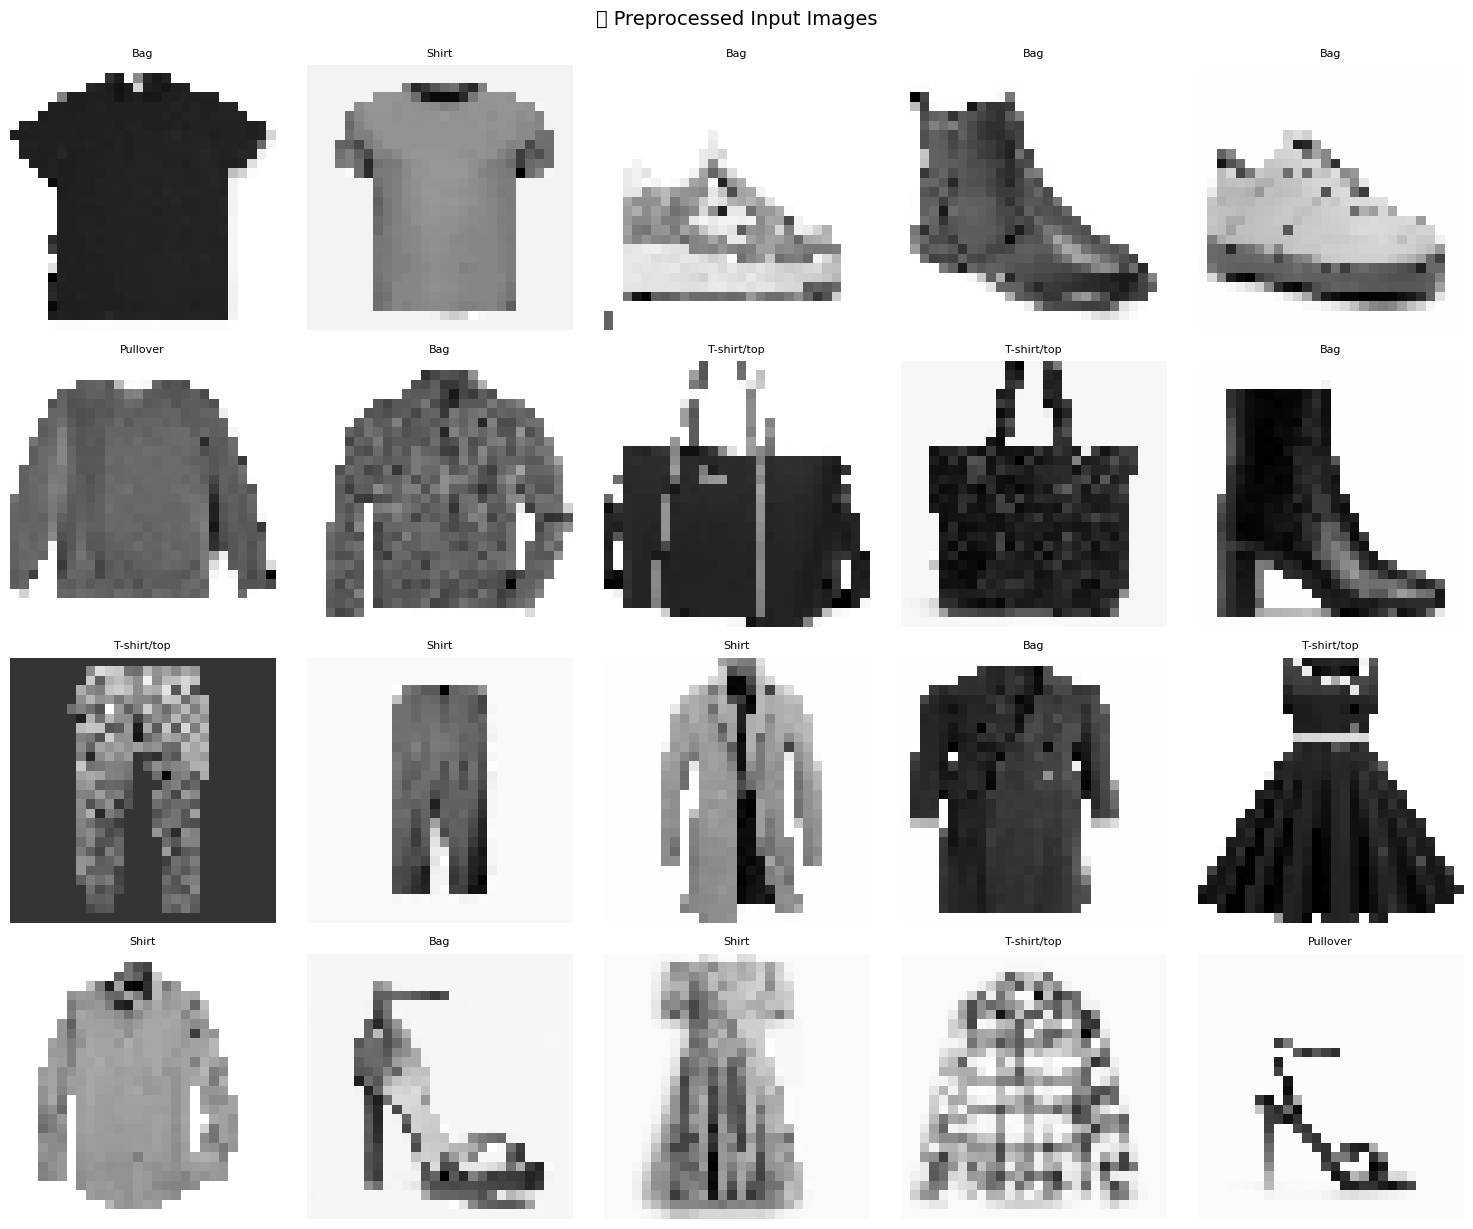

In [56]:
import math
import matplotlib.pyplot as plt

def visualize_preprocessed_images(images, labels=None, filenames=None):
    n = len(images)
    cols = 5
    rows = math.ceil(n / cols)

    plt.figure(figsize=(3 * cols, 3 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')

        # Title logic
        if labels is not None:
            title = labels[i]
        elif filenames is not None:
            title = filenames[i]
        else:
            title = f"Image {i+1}"

        plt.title(title, fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle("🧹 Preprocessed Input Images", fontsize=14, y=1.02)
    plt.show()


# Example usage
visualize_preprocessed_images(real_images, labels=[labels[l] for l in predicted_labels], filenames=filenames)


So as we can see our model does poorly when trying to classify real world images from google. We get a 90 percent accuracy on the test data from the MNIST Dataset.
Here is what we are going to do now. Create another model that will perform better with real world data with different ML techniques.

# 2. Data Augmented Model

We're applying random transforms to simulate real-world conditions.

rotation, shift, zoom, and brightness make the model robust to lighting and positioning.

ImageDataGenerator generates these variations on the fly during training.

In [57]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation pipeline
data_augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)


## Data Preparation for Augmentation (Grayscale to RGB)

In this block, we prepare our data to be compatible with `ImageDataGenerator`, which is typically designed for 3-channel (RGB) inputs.

- First, we preprocess the training and test data using the existing `preprocess_for_cnn()` function.
- Since the original FashionMNIST images are single-channel (grayscale), we convert each image to 3 identical channels using `np.repeat(...)`.
  - This does **not** add new color information — it just adjusts the shape from `(28, 28, 1)` to `(28, 28, 3)` for compatibility.
- A sample image is shown before augmentation to verify the conversion worked.
- We print the shape and pixel range of the sample to confirm it’s correctly formatted.
- Finally, we initialize the `ImageDataGenerator` with our RGB-converted training images to enable real-time augmentation (rotation, zoom, shift, etc.).


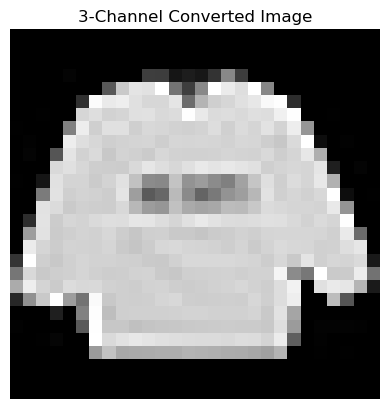

Shape: (28, 28, 3)
Min pixel: 0.0 Max pixel: 1.0


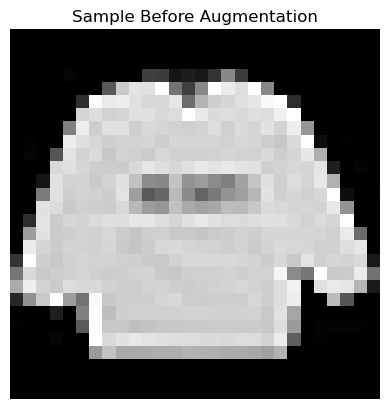

In [58]:
# Reuse existing preprocessed data functions
X_train_cnn, y_train_cnn = preprocess_for_cnn(training_df)
# Convert 1-channel grayscale to 3-channel grayscale to work with ImageDataGenerator
X_train_cnn_rgb = np.repeat(X_train_cnn, 3, axis=-1)

plt.imshow(X_train_cnn_rgb[0])
plt.title("3-Channel Converted Image")
plt.axis('off')
plt.show()

print("Shape:", X_train_cnn_rgb[0].shape)
print("Min pixel:", X_train_cnn_rgb[0].min(), "Max pixel:", X_train_cnn_rgb[0].max())

X_test_cnn, y_test_cnn = preprocess_for_cnn(test_df)

#plot the first sample before augmentation

plt.imshow(X_train_cnn[0].reshape(28, 28), cmap='gray')
plt.title("Sample Before Augmentation")
plt.axis('off')
plt.show()


# Create augmented data generator
augmented_train_generator = data_augmentor.flow(X_train_cnn_rgb, y_train_cnn, batch_size=128)



## Visualize a Batch of Augmented Images

This cell previews a batch of images generated by the `ImageDataGenerator`.

- We use `next(augmented_train_generator)` to fetch one batch of augmented images and labels.
- We then visualize 10 of those images to verify that the transformations are working as expected.
- Augmentations may include: rotation, zoom, width/height shift, etc.
- Additionally, we print the shape and pixel value range of the batch to confirm:
  - The batch dimensions are correct
  - Pixel values remain normalized between 0 and 1 after augmentation
- This step is crucial to catch any preprocessing issues *before* training.

Note: `cmap='gray'` is still used because even though the images are 3-channel, they are visually still grayscale copies.


Augmented batch shape: (128, 28, 28, 3)
Augmented batch pixel range: 0.0 - 1.0
Augmented batch shape: (128, 28, 28, 3)
Augmented batch pixel range: 0.0 - 1.0
Augmented batch shape: (128, 28, 28, 3)
Augmented batch pixel range: 0.0 - 1.0
Augmented batch shape: (128, 28, 28, 3)
Augmented batch pixel range: 0.0 - 1.0
Augmented batch shape: (128, 28, 28, 3)
Augmented batch pixel range: 0.0 - 1.0
Augmented batch shape: (128, 28, 28, 3)
Augmented batch pixel range: 0.0 - 1.0
Augmented batch shape: (128, 28, 28, 3)
Augmented batch pixel range: 0.0 - 1.0
Augmented batch shape: (128, 28, 28, 3)
Augmented batch pixel range: 0.0 - 1.0
Augmented batch shape: (128, 28, 28, 3)
Augmented batch pixel range: 0.0 - 1.0
Augmented batch shape: (128, 28, 28, 3)
Augmented batch pixel range: 0.0 - 1.0


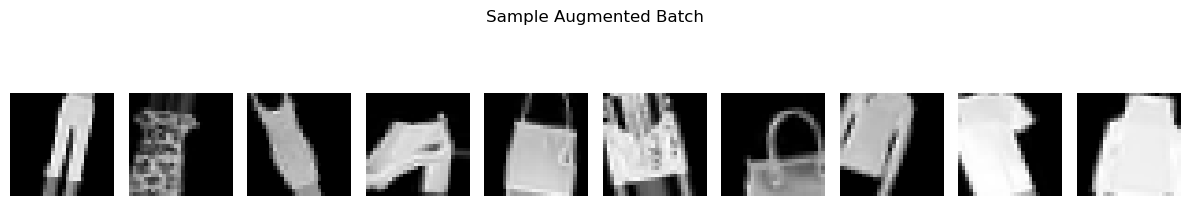

In [59]:
# Visualize a batch of augmented images
import matplotlib.pyplot as plt

x_batch, y_batch = next(augmented_train_generator)

plt.figure(figsize=(12, 2.5))
for i in range(10):
    plt.subplot(1, 10, i+1)
    print("Augmented batch shape:", x_batch.shape)
    print("Augmented batch pixel range:", x_batch.min(), "-", x_batch.max())
    plt.imshow(x_batch[i], cmap='gray')

    plt.axis('off')
plt.suptitle("Sample Augmented Batch")
plt.tight_layout()
plt.show()

A deeper CNN than the original (extra dropout and filters).

Still efficient and small enough for quick training.

More dropout = more regularization to generalize better.

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_augmented_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 3)),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


We train using the augmented generator, not just the raw data.

steps_per_epoch ensures full dataset is covered per epoch.

In [61]:
augmented_model = build_augmented_model()
augmented_model.summary()
X_test_cnn_rgb = np.repeat(X_test_cnn, 3, axis=-1)
# Train on augmented data
history_aug = augmented_model.fit(
    augmented_train_generator,
    epochs=10,
    validation_data=(X_test_cnn_rgb, y_test_cnn)
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,610 (881.29 KB)

 Trainable params: 225,610 (881.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.4552 - loss: 1.4601 - val_accuracy: 0.7163 - val_loss: 0.6895
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6674 - loss: 0.8901 - val_accuracy: 0.7595 - val_loss: 0.5992
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6961 - loss: 0.8110 - val_accuracy: 0.7733 - val_loss: 0.5472
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7148 - loss: 0.7606 - val_accuracy: 0.8024 - val_loss: 0.4972
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7300 - loss: 0.7282 - val_accuracy: 0.8050 - val_loss: 0.4839
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7380 - loss: 0.6982 - val_accuracy: 0.8161 - val_loss: 0.4772
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7525 - loss: 0.6748 - val_accuracy: 0.8316 - val_loss: 0.4347
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7564 - loss: 0.6619 - val_accurac

We see that our model has less accuracy now. But this maybe a good thing when it compares to real life images. It was overfitting for just the clean images in the dataset initially so the previous accuracy was higher

saving the model

In [62]:
augmented_model.save("augmented_fashion_cnn.keras")
print("✅ Augmented model saved as 'augmented_fashion_cnn.keras'")

✅ Augmented model saved as 'augmented_fashion_cnn.keras'


In [63]:
model2 = load_model("augmented_fashion_cnn.keras")

lets change the way we preprocess the google images now since we are using different techniques

In [64]:
import cv2
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image

def preprocess_and_clean_images(folder_path):
    image_data = []
    image_names = []

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, filename)

            # Load as grayscale (OpenCV loads in BGR by default)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            # Resize to something manageable before thresholding
            img = cv2.resize(img, (100, 100))

            # Apply adaptive threshold to create a mask
            thresh = cv2.adaptiveThreshold(img, 255, 
                                           cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                           cv2.THRESH_BINARY_INV, 
                                           11, 2)

            # Mask the image (keep clothing, remove background)
            cleaned = cv2.bitwise_and(img, img, mask=thresh)

            # Resize to 28x28 (final shape for classifier)
            cleaned_resized = cv2.resize(cleaned, (28, 28))

            # Normalize to [0,1] and add channel dimension
            normalized = cleaned_resized.astype('float32') / 255.0
            normalized = normalized.reshape(28, 28, 1)

            image_data.append(normalized)
            image_names.append(filename)

    return np.array(image_data), image_names


Lets do the predictions on the google images with this model now

In [65]:


# Load & predict
real_images_cleaned, real_filenames = preprocess_and_clean_images(real_image_folder)
real_images_cleaned_rgb = np.repeat(real_images_cleaned, 3, axis=-1)  # for augmented model


preds = augmented_model.predict(real_images_cleaned_rgb)
predicted_labels = np.argmax(preds, axis=1)

for fname, label in zip(real_filenames, predicted_labels):
    print(f"{fname}: Predicted → {labels[label]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
tshirt2.png: Predicted → Sandal
tshirt1.png: Predicted → Bag
sneaker1.png: Predicted → Sandal
ankleboot2.png: Predicted → Sandal
sneaker2.png: Predicted → Sandal
pullover1.png: Predicted → Bag
pullover2.png: Predicted → Shirt
bag1.png: Predicted → Bag
bag2.png: Predicted → Bag
ankleboots1.png: Predicted → Dress
trouser1.png: Predicted → Shirt
trouser2.jpeg: Predicted → Bag
coat1.png: Predicted → Bag
coat2.png: Predicted → T-shirt/top
dress2.jpg: Predicted → Dress
shirt1.png: Predicted → Bag
sandal1.png: Predicted → Bag
dress1.png: Predicted → Dress
shirt2.png: Predicted → Shirt
sandal2.png: Predicted → Sandal


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


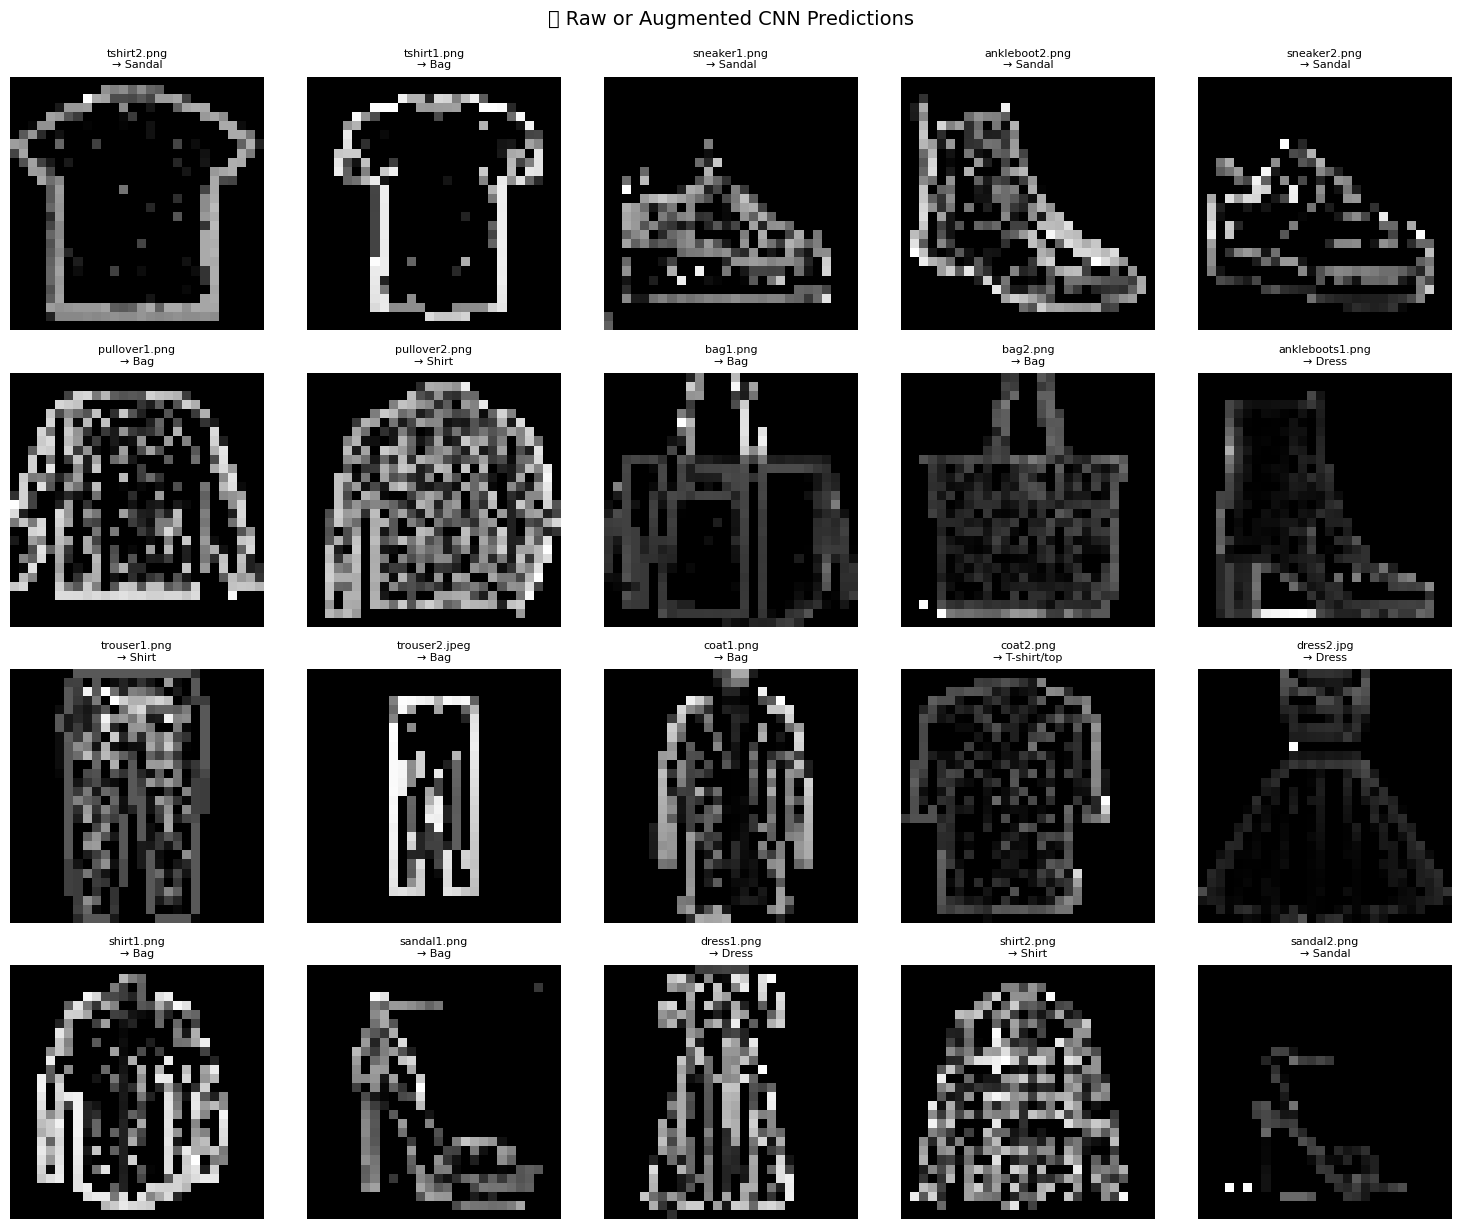

In [66]:
import matplotlib.pyplot as plt
import math
import matplotlib.pyplot as plt

def visualize_real_predictions(images, filenames, predicted_labels, label_map):
    n = len(images)
    cols = 5
    rows = math.ceil(n / cols)

    plt.figure(figsize=(3 * cols, 3 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f"{filenames[i]}\n→ {label_map[predicted_labels[i]]}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle("🧠 Raw or Augmented CNN Predictions", fontsize=14, y=1.02)
    plt.show()
visualize_real_predictions(real_images_cleaned, real_filenames, predicted_labels, labels)


As we can see we did a bunch of data augmentation and preprocessing techniques to the google images but the results are not satisfactory. The mnist dataset is prepared with clean image data with the objects centered and with black backgrounds. We went out of the way to try and make the google images preprocessing look close to what the mnist preprocessed data set with the data augmentation looks like. We still get bad results as it is hard to preprocess our data that way.


Now lets try with a completely different image classification approach. This is the thought process currently. I feel that the image classification models are too reliant on the coloring of the images and feel like it would work so much better with real life images if it focused on learning the edges of the objects to better predict what object it is.

So now we use the FashionMNIST training dataset, but instead of training on raw grayscale pixel values, we want to train a model to learn from the edges or structure of those images, then we test this trained model on our Google images, after applying similar edge-focused preprocessing.

# 3. Edge Based CNN

In [67]:
##  Preprocess MNIST (we already did this but lets redo it)
X_train_cnn, y_train_cnn = preprocess_for_cnn(training_df)
X_test_cnn, y_test_cnn = preprocess_for_cnn(test_df)


This function converts a batch of grayscale images into edge maps using OpenCV's `Canny()` edge detection algorithm.

In [68]:
import cv2
import numpy as np

def convert_to_edge_maps(images, threshold1=100, threshold2=200):
    """
    Apply Canny edge detection to a batch of grayscale images.
    Input shape: (N, 28, 28, 1), output: (N, 28, 28, 1)
    """
    edge_maps = []
    for img in images:
        img_uint8 = (img.squeeze() * 255).astype(np.uint8)
        edges = cv2.Canny(img_uint8, threshold1, threshold2)
        edges = edges.astype('float32') / 255.0
        edges = edges.reshape(28, 28, 1)
        edge_maps.append(edges)
    return np.array(edge_maps)


In [69]:
#  Create edge-detected versions of train/test sets
X_train_edges = convert_to_edge_maps(X_train_cnn)
X_test_edges = convert_to_edge_maps(X_test_cnn)


Lets take a look at how the edge maps would look like

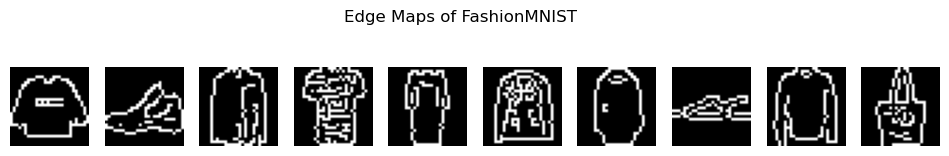

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train_edges[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Edge Maps of FashionMNIST")
plt.show()


## Data Augmentation for Edge-Based CNN

This block sets up **data augmentation** specifically for training the **Edge-Based CNN**.

Since edge maps are more sensitive to small transformations, we apply light geometric augmentations to:
- Improve generalization
- Simulate slight variations in pose, orientation, and position
- Help the model become robust to imperfect real-world outlines

- `rotation_range=10`: small rotations to simulate tilt
- `width/height_shift_range=0.1`: slight shifts left/right or up/down
- `zoom_range=0.1`: random zoom in/out
- `fill_mode='constant', cval=0.0`: pads shifted pixels with black (0), preserving the edge-only nature of the image

We use `flow()` to wrap the edge images and labels into a Keras generator that provides augmented batches during training.Lets do the data augmentation to the edge graphs from the dataset

In [71]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

edge_augmentor = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='constant',
    cval=0.0
)

edge_augmented_train_generator = edge_augmentor.flow(
    X_train_edges, y_train_cnn, batch_size=128
)


## Build Edge-Based CNN Model

This function defines the architecture of our third model: the **Edge-Based CNN**.

- Takes input shape `(28, 28, 1)` representing edge-detected grayscale images

 Architecture
- **Conv2D (32 filters)** → **MaxPooling** → **Dropout**
- **Conv2D (64 filters)** → **MaxPooling** → **Dropout**
- **Flatten** → **Dense (128 units)** → **Dropout**
- **Output**: 10-unit softmax for FashionMNIST classification

Compilation
- Optimizer: `Adam` — good default for most CNNs
- Loss: `sparse_categorical_crossentropy` — used because our labels are integer class indices
- Metric: `accuracy`

This model learns to classify clothing based only on **shape and contour** features, rather than raw pixel values.

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_edge_cnn_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

edge_model = build_edge_cnn_model()
edge_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Inspect Test Label Format

In [73]:
print(y_test_cnn.shape)
print(y_test_cnn[0])


(10000, 10)
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## Train Edge-Based CNN with Sparse Labels

Convert One-Hot Labels to Sparse
We use `np.argmax()` to convert one-hot encoded labels (`y_train_cnn`, `y_test_cnn`) to integer class indices.
This is necessary because the model uses `sparse_categorical_crossentropy`, which expects integer labels.

 Create Augmented Generator
We reinitialize the edge augmentation generator with the new sparse labels to ensure compatibility.

Train the Edge-Based CNN
We train the model for 10 epochs using:
- Augmented edge-detected training images
- Corresponding sparse integer labels
- Validation set: edge-processed FashionMNIST test images

This training setup focuses on helping the model generalize well using **only shape and outline** information.


In [74]:
import numpy as np

# Convert y_test_cnn and y_train_cnn to sparse labels
y_test_sparse = np.argmax(y_test_cnn, axis=1)
y_train_sparse = np.argmax(y_train_cnn, axis=1)

# Create the augmented generator using sparse labels
edge_augmented_train_generator = edge_augmentor.flow(
    X_train_edges, y_train_sparse, batch_size=128
)

# Train the model
history_edge = edge_model.fit(
    edge_augmented_train_generator,
    epochs=10,
    validation_data=(X_test_edges, y_test_sparse)
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.5043 - loss: 1.2925 - val_accuracy: 0.7673 - val_loss: 0.6075
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7101 - loss: 0.7649 - val_accuracy: 0.8050 - val_loss: 0.5207
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7397 - loss: 0.6881 - val_accuracy: 0.8077 - val_loss: 0.4978
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7550 - loss: 0.6484 - val_accuracy: 0.8180 - val_loss: 0.4670
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7646 - loss: 0.6201 - val_accuracy: 0.8281 - val_loss: 0.4467
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7698 - loss: 0.6070 - val_accuracy: 0.8261 - val_loss: 0.4488
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7746 - loss: 0.5944 - val_accuracy: 0.8277 - val_loss: 0.4410
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7792 - loss: 0.5836 - val_accu

We see around the same accuracy as just the data augmented model, but this is still a good sign. It proves it can predict based of the edges pretty well.

## Preprocess Google Images into Edge Maps

This function is used to convert real-world `.jpg` or `.png` images into binary edge maps suitable for inference with our **Edge-Based CNN**.

What it does:
- Loads each image from the provided folder in **grayscale**
- Resizes to **28×28** to match FashionMNIST input shape
- Applies **Canny edge detection** to extract structural outlines
- Normalizes the output to `[0, 1]` and reshapes to `(28, 28, 1)`

 Returns:
- `image_data`: numpy array of edge-processed image tensors
- `image_names`: list of filenames to track predictions later

This keeps our inference pipeline consistent with how the model was trained — purely on shape.

In [75]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def preprocess_google_images_to_edges(folder_path):
    image_data = []
    image_names = []

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, filename)

            # Load image in grayscale
            img = load_img(img_path, color_mode='grayscale', target_size=(28, 28))
            img_array = img_to_array(img).squeeze()  # (28, 28)

            # Convert to uint8 and apply Canny edge detection
            img_uint8 = img_array.astype(np.uint8)
            edges = cv2.Canny(img_uint8, threshold1=100, threshold2=200)

            # Normalize to 0-1 and reshape to (28, 28, 1)
            edges = edges.astype('float32') / 255.0
            edges = edges.reshape(28, 28, 1)

            image_data.append(edges)
            image_names.append(filename)

    return np.array(image_data), image_names


In [76]:
#performing the edge detection on the google images
real_edge_images, real_filenames = preprocess_google_images_to_edges(real_image_folder)


In [77]:
# Load the model and make predictions
edge_predictions = edge_model.predict(real_edge_images)
predicted_classes = np.argmax(edge_predictions, axis=1)

for fname, pred in zip(real_filenames, predicted_classes):
    print(f"{fname}: Predicted → {labels[pred]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
tshirt2.png: Predicted → T-shirt/top
tshirt1.png: Predicted → T-shirt/top
sneaker1.png: Predicted → Sandal
ankleboot2.png: Predicted → Bag
sneaker2.png: Predicted → Bag
pullover1.png: Predicted → Pullover
pullover2.png: Predicted → Coat
bag1.png: Predicted → Bag
bag2.png: Predicted → Bag
ankleboots1.png: Predicted → Bag
trouser1.png: Predicted → Trouser
trouser2.jpeg: Predicted → Trouser
coat1.png: Predicted → Coat
coat2.png: Predicted → T-shirt/top
dress2.jpg: Predicted → Dress
shirt1.png: Predicted → Shirt
sandal1.png: Predicted → Dress
dress1.png: Predicted → Dress
shirt2.png: Predicted → Shirt
sandal2.png: Predicted → Bag


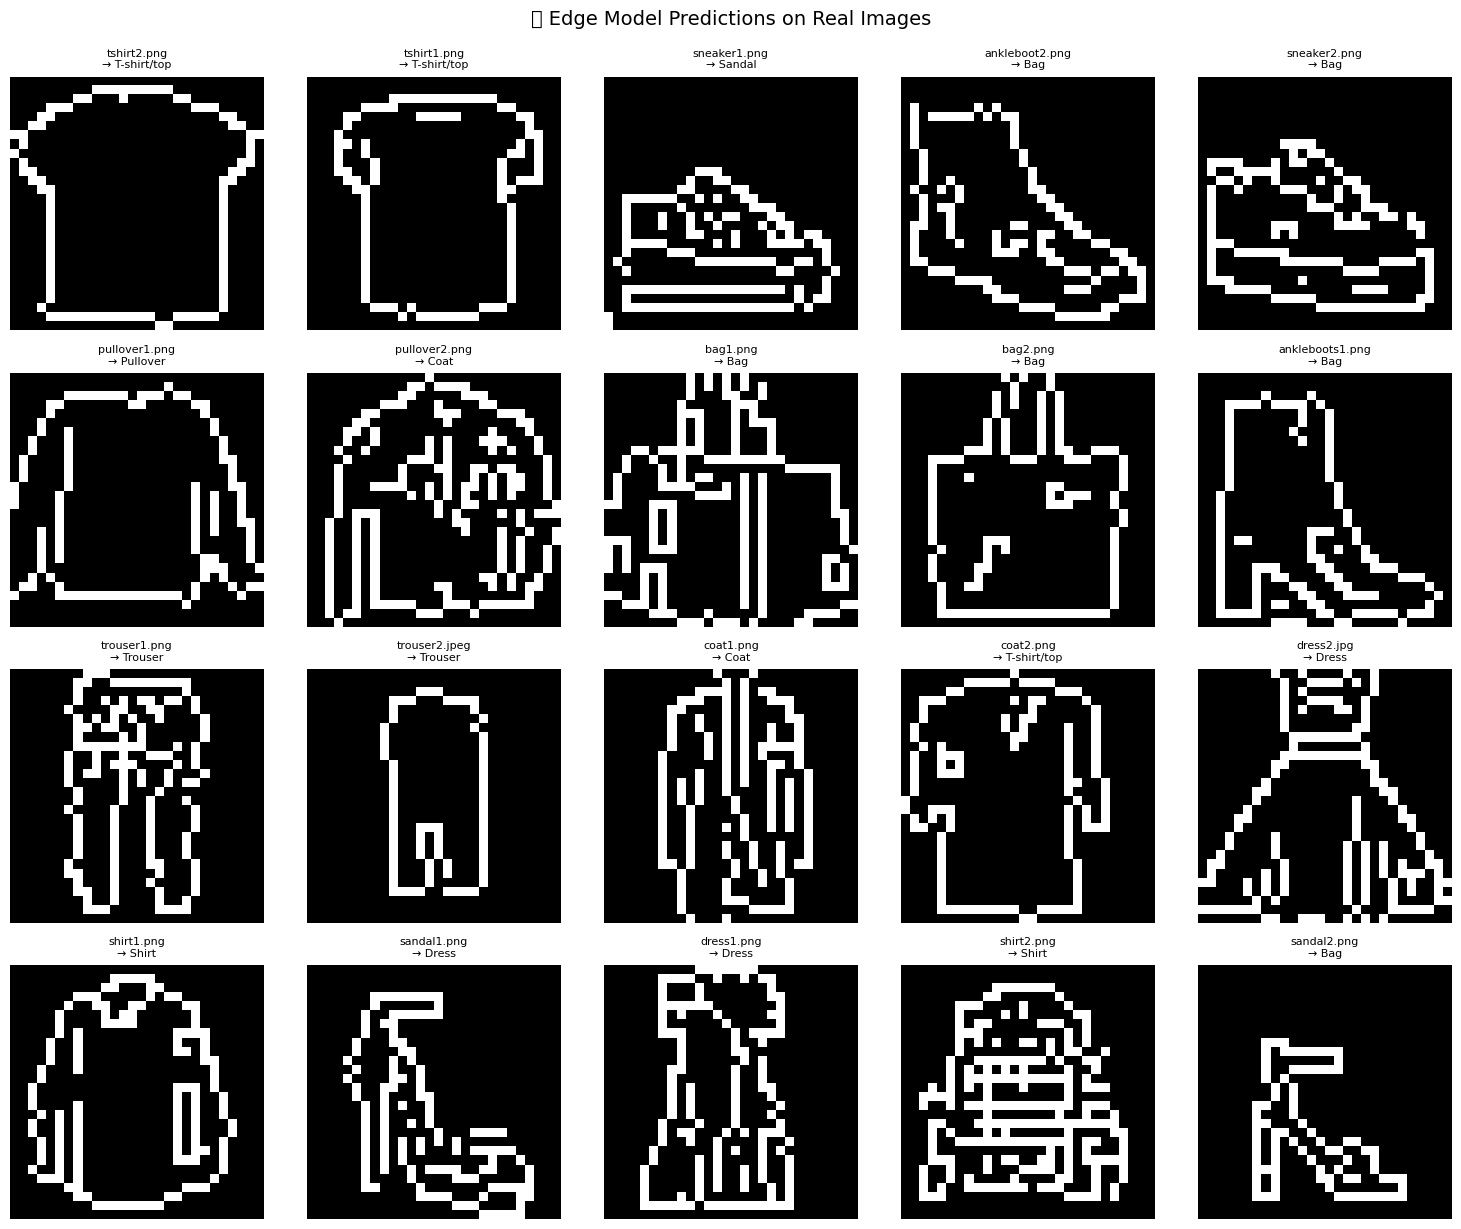

In [78]:
import matplotlib.pyplot as plt
import math

def visualize_edge_predictions(images, filenames, predicted_labels, label_map):
    n = len(images)
    cols = 5
    rows = math.ceil(n / cols)
    plt.figure(figsize=(3 * cols, 3 * rows))

    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f"{filenames[i]}\n→ {label_map[predicted_labels[i]]}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle("🧠 Edge Model Predictions on Real Images", fontsize=14, y=1.02)
    plt.show()

# Call it
visualize_edge_predictions(real_edge_images, real_filenames, predicted_classes, labels)


# Conclusion: The Edge-Based CNN Outperformed
We really like the results from the Edge Based CNN model. it is able to predict real images of clothes much better than the previous models. Looks like having more emphasis on predicting based of the edges is much better. 

The Edge-Based CNN demonstrated significantly better generalization to real-world images compared to the baseline and augmented models.

 Key reasons:
- It learned from **shape and contour** only, removing biases from texture, color, and lighting.
- Edge preprocessing eliminated noisy backgrounds, making object outlines more consistent.
- Augmentation on edge maps (rotation, shift, zoom) helped it handle real-world variations.

This model's success shows that emphasizing **structural features** over raw pixel data is a highly effective strategy for fashion classification in uncontrolled environments.

Why it still makes mistakes:
-  **Some clothing items share similar silhouettes** — for example:
  - **Shirts vs Pullovers**
  - **Bags vs Ankle boots** (from a side angle)
-  **Edge maps are sparse** — they contain less information than full images, which can lead to confusion when two classes have similar outlines.
- **Real-world image quality varies** — poor lighting, blurriness, or low resolution can degrade the edge map quality.

While this model generalizes better than previous versions, further improvements could include combining edge maps with grayscale inputs (dual-input models), or fine-tuning on labeled real-world examples to learn subtle differences, or even using some other more advanced image classification models.


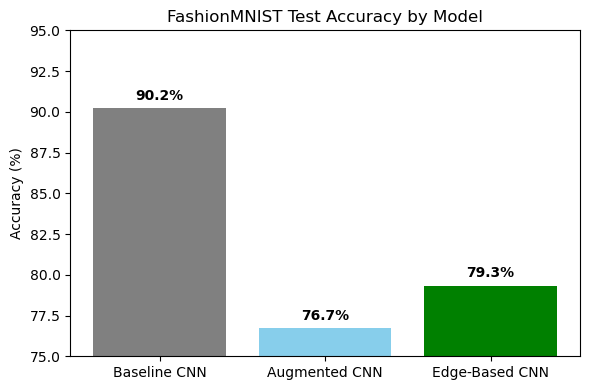

In [85]:
import matplotlib.pyplot as plt

# Accuracy values
mnist_accuracies = [90.24, 76.73, 79.34]
mnist_labels = ['Baseline CNN', 'Augmented CNN', 'Edge-Based CNN']

# Create plot
plt.figure(figsize=(6, 4))
bars = plt.bar(mnist_labels, mnist_accuracies, color=['gray', 'skyblue', 'green'])
plt.ylim(75, 95)  # Zoom in on range
plt.ylabel("Accuracy (%)")
plt.title("FashionMNIST Test Accuracy by Model")

# Add accuracy labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.5, f"{height:.1f}%", ha='center', fontsize=10, fontweight='bold')

# Remove gridlines
plt.grid(False)

# Display chart
plt.tight_layout()
plt.show()


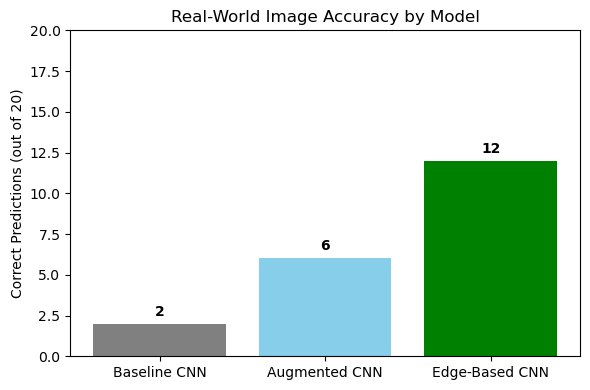

In [87]:
import matplotlib.pyplot as plt

# Correct predictions on 20 real-world Google images
real_world_correct = [2, 6, 12]  # Baseline, Augmented, Edge
mnist_labels = ['Baseline CNN', 'Augmented CNN', 'Edge-Based CNN']

# Create plot
plt.figure(figsize=(6, 4))
bars = plt.bar(mnist_labels, real_world_correct, color=['gray', 'skyblue', 'green'])
plt.ylim(0, 20)
plt.ylabel("Correct Predictions (out of 20)")
plt.title("Real-World Image Accuracy by Model")

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.5, f"{int(height)}", ha='center', fontsize=10, fontweight='bold')

# Remove gridlines
plt.grid(False)

# Display chart
plt.tight_layout()
plt.show()
